In [2]:
from pyTNG import utils
from pyTNG import data_interface as _data_interface
import os
import pandas as pd
import numpy as np
import illustris_python as il
from pyTNG.spectra import StarSpectrumFactory
from pyTNG import spectra
import matplotlib.pyplot as plt
import time
import astropy.units as u
import scipy.integrate as integ
import pyTNG.utils as utils
from pyTNG.cosmology import TNGcosmo

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
h = TNGcosmo.h
snap_num = 13

In [5]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [6]:
basepath = "/virgotng/universe/IllustrisTNG/"
sim_name = 'L35n2160TNG'
sim = _data_interface.TNG50Simulation(os.path.join(basepath, sim_name))

In [7]:
dataset = next(sim.group_cat[snap_num].chunk_generator('subhalo'))

In [9]:
keys_needed = ['SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloHalfmassRadType', 'SubhaloMassInHalfRad', 
               'SubhaloMassInHalfRadType', 'SubhaloMassInRad', 'SubhaloMassInRadType', 'SubhaloSFRinHalfRad', 
               'SubhaloSFRinRad', 'SubhaloPos']

In [10]:
sub_dict = {key: dataset[key] for key in keys_needed}

In [11]:
dataset_df = utils.dfFromArrDict(sub_dict)

In [12]:
columns_of_interest = [('SubhaloGasMetallicity', 0), 
                       ('SubhaloGasMetallicityHalfRad',0),
                       ('SubhaloHalfmassRadType', 4),
                       ('SubhaloMassInHalfRad', 0),
                       ('SubhaloMassInHalfRadType', 0),
                       ('SubhaloMassInHalfRadType', 4),
                       ('SubhaloMassInRad', 0),
                       ('SubhaloMassInRadType', 0),
                       ('SubhaloMassInRadType', 4),
                       ('SubhaloSFRinHalfRad', 0),
                       ('SubhaloSFRinRad', 0),
                       ('SubhaloPos', 0),
                       ('SubhaloPos', 1),
                       ('SubhaloPos', 2)
                      ]

Remove all halos that do not have any star particles or star formation rate

In [13]:
def reduce_df(df):
    filt = (df[('SubhaloMassInRadType', 4)]>0) & (df[('SubhaloSFRinRad', 0)]>0)
    new_df = df[filt]
    return new_df

In [14]:
df_to_save = dataset_df[columns_of_interest]
df_to_save = reduce_df(df_to_save)

In [13]:
path = '/ptmp/mpa/ivkos/semianalytic_fesc/testing/sn013.pickle'
df_to_save.to_pickle(path)

NameError: name 'df_to_save' is not defined

In [16]:
path = '/ptmp/mpa/ivkos/semianalytic_fesc/testing/sn013.pickle'
df = pd.read_pickle(path)

In [17]:
z_start = sim.snap_cat[snap_num].header['Redshift']

In [18]:
sim_path = os.path.join(basepath, sim_name, 'output')

In [10]:
bpp = [
    '/ptmp/mpa/mglatzle/TNG_f_esc/BPASSv2.2.1_release-07-18-Tuatara/',
    '2.2.1',
    'chab300',
    'bin']
lam_min = None
lam_max = None
specFac = StarSpectrumFactory(bpp)

In [11]:
def get_stellar_dist(stars, df, index):
    gal_center = np.array([df.loc[index][('SubhaloPos',0)],df.loc[index][('SubhaloPos',1)],df.loc[index][('SubhaloPos',2)]])
    rel_pos = stars['Coordinates']-gal_center
    radius = df.loc[index][('SubhaloHalfmassRadType',4)]*2
    dist = np.sqrt(np.sum(np.square(rel_pos), axis=1))
    rel_dist = dist/radius
    stars['rel_dist'] = rel_dist
    return

In [ ]:
def add_luminosities(df):
    idx = 0
    stars = il.snapshot.loadSubhalo(sim_path, snap_num, idx,'stars')
    print(stars['count'])
    utils.dropWindParticles(stars)
    stars['Redshift'] = z_start
    stars['ages'] = spectra._computeAgeFromFormationTime(stars['Redshift'],stars['GFM_StellarFormationTime'])
    get_stellar_dist(stars, df, idx)
    idces = stars['rel_dist']<1
    utils._keepPartsByIdx(stars, idces)
    if stars['count']<10000:
        specFac.computeStellarSpectra(stars, Q_0=True)
        ion_lum = stars['Q_0'].sum()
        summed_spectrum = stars['spectra'].sum(axis=0)
        luminosity = integ.simps(summed_spectrum, stars['lambda'])
    else:
        print(stars['count'])
        star_arr = star_batches(stars, batchsize=10000)
        ion_lum, luminosity = calculate_batched_quants(star_arr)
    df.loc[idx]['luminosity'] = luminosity
    df.loc[idx]['ion_lum'] = ion_lum
    del stars
    del star_arr
    return

In [30]:
def add_lum_ion(df, sim_path, snap_num):
    luminosities = []
    ion_lums = []
    df[('ion_lum',0)] = np.nan
    df[('luminosity',0)] = np.nan
    for idx in df.index:
        stars = il.snapshot.loadSubhalo(sim_path, snap_num, idx,'stars')
        utils.dropWindParticles(stars)
        stars['Redshift'] = z_start
        stars['ages'] = spectra._computeAgeFromFormationTime(stars['Redshift'],stars['GFM_StellarFormationTime'])
        get_stellar_dist(stars, df, idx)
        idces = stars['rel_dist']<1
        utils._keepPartsByIdx(stars, idces)
        specFac.computeStellarSpectra(stars, Q_0=True)
        ion_lum = stars['Q_0'].sum()
        summed_spectrum = stars['spectra'].sum(axis=0)
        luminosity = integ.simps(summed_spectrum, stars['lambda'])
        luminosities.append(luminosity)
        ion_lums.append(ion_lum)
        del stars
    return

Units: <br>
all masses: 10^10M_sun/h <br>
SFR: M_sun/h/s <br>
Radius: ckpc/h <br>
Luminosity: L_sun <br>

In [13]:
def build_new_df(df, path, z, h):
    new_df = pd.DataFrame()
    new_df['HaloMass'] = df[('SubhaloMassInRad',0)]
    new_df['GasMass'] = df[('SubhaloMassInRadType',0)]
    new_df['StarMass'] = df[('SubhaloMassInRadType',4)]
    new_df['SFR'] = df[('SubhaloSFRinRad',0)]
    new_df['com_radius'] = 2*df[('SubhaloHalfmassRadType',4)]
    new_df['Z'] = df[('SubhaloGasMetallicity',0)]
    new_df['ion_lum'] = df[('ion_lum',0)]
    new_df['luminosity'] = df[('luminosity',0)]
    
    new_df['radius'] = (z+1)*new_df[com_radius]/h
    new_df['gas_surface_dens'] = 1e10*new_df['GasMass']/(h*np.pi*new_df['radius']**2)
    new_df['star_surface_dens'] = 1e10*new_df['StarMass']/(h*np.pi*new_df['radius']**2)
    new_df['sfr_surface_dens'] = new_df['SFR']/(np.pi*new_df['radius']**2)
    new_df['ionizing_flux'] = new_df['ion_lum']/(np.pi*new_df['radius']**2)
    new_df.to_pickle(path)
    return

In [11]:
df.loc[3]

SubhaloGasMetallicity         0        0.001956
SubhaloGasMetallicityHalfRad  0        0.003759
SubhaloHalfmassRadType        4       13.317231
SubhaloMassInHalfRad          0        0.193574
SubhaloMassInHalfRadType      4        0.002193
SubhaloMassInRad              0        0.471234
SubhaloMassInRadType          0        0.042249
                              4        0.003220
SubhaloSFRinHalfRad           0        0.078287
SubhaloSFRinRad               0        0.122709
SubhaloPos                    0    24364.863281
                              1    18031.574219
                              2    14490.092773
Name: 3, dtype: float64

In [128]:
stars = il.snapshot.loadSubhalo(sim_path, snap_num, 2,'stars')
utils.dropWindParticles(stars)
stars['Redshift'] = z_start
stars['ages'] = spectra._computeAgeFromFormationTime(stars['Redshift'],stars['GFM_StellarFormationTime'])

In [129]:
gas = il.snapshot.loadSubhalo(sim_path, snap_num, 2,'gas')

In [195]:
def get_star_forming_gas(gas):
    star_forming_gas = {}
    star_forming = gas['StarFormationRate']>1e-9
    star_forming_gas['SFR'] = gas['StarFormationRate'][star_forming]
    star_forming_gas['Centers'] = gas['Coordinates'][star_forming]
    star_forming_gas['Densities'] = gas['Density'][star_forming]
    star_forming_gas['Z'] = gas['GFM_Metallicity'][star_forming]
    star_forming_gas['Masses'] = gas['Masses'][star_forming]
    star_forming_gas['count'] = np.sum(star_forming)
    return star_forming_gas

In [131]:
def get_radius_vol(gas):
    gas['Radii'] = ((3/(4*np.pi)*gas['Masses']/gas['Densities']))**(1/3)
    gas['Volumes'] = gas['Masses']/gas['Densities']
    return gas

In [132]:
def get_stellar_dist_gas(stars, gas_coord, gas_rad):
    rel_pos = stars['Coordinates']-gas_coord
    dist = np.sqrt(np.sum(np.square(rel_pos), axis=1))
    rel_dist = dist/gas_rad
    stars['rel_dist'] = rel_dist
    return

In [220]:
def select_stars_in_gas(stars, gas):
    relevant_stars = {}
    for key in stars.keys():
        if key == 'count':
            relevant_stars[key] = 0
        elif key == 'Redshift':
            relevant_stars[key] = stars[key]
        else:
            relevant_stars[key] = []
    for i, center in enumerate(gas['Centers']):
        get_stellar_dist_gas(stars, center, gas['Radii'][i])
        new_stars = stars['rel_dist']<1
        for key in stars.keys():
            if key not in {'count', 'Redshift', 'rel_dist'}:
                relevant_stars[key].extend(stars[key][new_stars])
                stars[key] = np.delete(stars[key], new_stars, axis=0)
        relevant_stars['count'] += np.sum(new_stars)
    for key in stars.keys():
        if key not in {'count', 'Redshift', 'rel_dist'}:
            relevant_stars[key] = np.array(relevant_stars[key])
    return relevant_stars

In [223]:
relevant_gas.keys()

dict_keys(['SFR', 'Centers', 'Densities', 'Z', 'Masses', 'count', 'Radii', 'Volumes'])

In [219]:
for index in df.index[1:40]:
    stars = il.snapshot.loadSubhalo(sim_path, snap_num, index ,'stars')
    utils.dropWindParticles(stars)
    stars['Redshift'] = z_start
    stars['ages'] = spectra._computeAgeFromFormationTime(stars['Redshift'],stars['GFM_StellarFormationTime'])
    gas = il.snapshot.loadSubhalo(sim_path, snap_num, index,'gas')
    relevant_gas = get_star_forming_gas(gas)
    get_radius_vol(relevant_gas)
    relevant_stars = select_stars_in_gas(stars, relevant_gas)
    print(relevant_stars['count']/stars['count'])
    for key in relevant_stars.keys():
        try:
            print(len(relevant_stars[key]))
        except:
            print(relevant_stars[key])
    print('='*80)

3242
0.4780999383096854
1550
1550
1550
1550
1550
1550
1550
1550
1550
1550
1550
1550
1550
1550
1550
1550
1550
1550
1550
1550
6.0107573988449
1550
2021
0.4685799109351806
947
947
947
947
947
947
947
947
947
947
947
947
947
947
947
947
947
947
947
947
6.0107573988449
947
839
0.33253873659118
279
279
279
279
279
279
279
279
279
279
279
279
279
279
279
279
279
279
279
279
6.0107573988449
279
912
0.4375
399
399
399
399
399
399
399
399
399
399
399
399
399
399
399
399
399
399
399
399
6.0107573988449
399
2856
0.5294117647058824
1512
1512
1512
1512
1512
1512
1512
1512
1512
1512
1512
1512
1512
1512
1512
1512
1512
1512
1512
1512
6.0107573988449
1512
369
0.35501355013550134
131
131
131
131
131
131
131
131
131
131
131
131
131
131
131
131
131
131
131
131
6.0107573988449
131
435
0.49195402298850577
214
214
214
214
214
214
214
214
214
214
214
214
214
214
214
214
214
214
214
214
6.0107573988449
214
236
0.4406779661016949
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
104
6.0

In [ ]:
np.array(times)/np.array(stars_count)

In [170]:
test = il.snapshot.loadSubhalo(sim_path, snap_num, 0 ,'stars')

In [171]:
test['count']

646048

In [189]:
test2 = il.snapshot.loadSubhalo(sim_path, snap_num, df.index[67] ,'stars')

In [190]:
test2['count']

124065

In [191]:
test2 = il.snapshot.loadSubhalo(sim_path, snap_num, df.index[67] ,'gas')

In [194]:
0.00449771*1e5/3600

0.12493638888888889

In [ ]:
relevant_gas = get_star_forming_gas(gas)
get_radius_vol(relevant_gas)
relevant_stars, min_ar, max_ar = select_stars_in_gas(stars, relevant_gas)

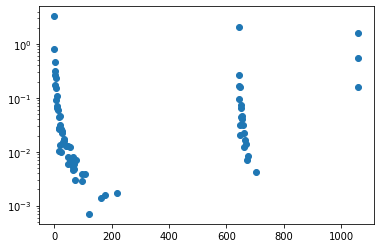

In [186]:
plt.scatter(df.index[:70], df.SubhaloMassInRad[:70])
plt.yscale('log')

In [135]:
print(np.min(min_ar))
print(np.max(min_ar))

print(np.min(max_ar))
print(np.max(max_ar))

0.027395240465465997
47.88389435633718
116.06117531315387
1087.5247776463027


In [136]:
relevant_stars['count']

947

In [137]:
stars['count']

2021

In [127]:
gas['count']

59095

In [112]:
relevant_gas['count']

3092

In [ ]:
relevant_gas = get_star

In [43]:
stars.keys()

dict_keys(['count', 'BirthPos', 'BirthVel', 'Coordinates', 'GFM_InitialMass', 'GFM_Metallicity', 'GFM_Metals', 'GFM_MetalsTagged', 'GFM_StellarFormationTime', 'GFM_StellarPhotometrics', 'Masses', 'ParticleIDs', 'Potential', 'StellarHsml', 'SubfindDMDensity', 'SubfindDensity', 'SubfindHsml', 'SubfindVelDisp', 'TimeStep', 'Velocities', 'Redshift', 'ages'])

In [35]:
gas.keys()

dict_keys(['count', 'CenterOfMass', 'Coordinates', 'Density', 'ElectronAbundance', 'EnergyDissipation', 'GFM_AGNRadiation', 'GFM_CoolingRate', 'GFM_Metallicity', 'GFM_Metals', 'GFM_MetalsTagged', 'GFM_WindDMVelDisp', 'GFM_WindHostHaloMass', 'InternalEnergy', 'InternalEnergyOld', 'Machnumber', 'MagneticField', 'MagneticFieldDivergence', 'Masses', 'NeutralHydrogenAbundance', 'ParticleIDs', 'Potential', 'Pressure', 'StarFormationRate', 'SubfindDMDensity', 'SubfindDensity', 'SubfindHsml', 'SubfindVelDisp', 'TimeStep', 'TimebinHydro', 'Velocities'])

In [34]:
star_form_gas = gas[gas['StarFormationRate']>1e-9]

TypeError: unhashable type: 'numpy.ndarray'

In [21]:
stars

{'count': 839,
 'BirthPos': array([[24392.219, 18000.33 , 14486.287],
        [24446.89 , 17939.096, 14481.394],
        [24430.994, 17957.83 , 14481.46 ],
        ...,
        [24707.67 , 17686.7  , 14422.515],
        [24535.207, 17819.783, 14429.135],
        [24339.473, 18048.809, 14583.178]], dtype=float32),
 'BirthVel': array([[-21.044567 ,  23.172894 ,   1.3226455],
        [-20.653309 ,  20.029716 ,   2.2585235],
        [-21.104048 ,  21.70938  ,   3.6946678],
        ...,
        [-15.851844 ,   8.649974 ,  -2.3258739],
        [-16.351942 ,  11.99236  ,   4.6247315],
        [-28.605433 ,  31.937803 ,   6.880994 ]], dtype=float32),
 'Coordinates': array([[24364.76548803, 18031.94515479, 14490.07894127],
        [24364.42979984, 18031.13904494, 14490.40675889],
        [24364.77926417, 18032.38568795, 14490.88037988],
        ...,
        [24389.15435489, 17978.07160794, 14482.52048033],
        [24394.11728012, 18008.01627702, 14465.22181288],
        [24337.049168  , 18051.

In [48]:
df.drop(index=874235, inplace=True)

In [52]:
z_start

6.0107573988449

In [46]:
start = time.time()
idx = 874235
stars = il.snapshot.loadSubhalo(sim_path, snap_num, idx,'stars')
print(stars['count'])
utils.dropWindParticles(stars)
stars['Redshift'] = z_start
stars['ages'] = spectra._computeAgeFromFormationTime(stars['Redshift'],stars['GFM_StellarFormationTime'])
print(stars['count'])
get_stellar_dist(stars, df, idx)
idces = stars['rel_dist']<1
utils._keepPartsByIdx(stars, idces)
print(stars['count'])
print(stars)
#specFac.computeStellarSpectra(stars, Q_0=True)

3
3
0
{'count': 0, 'BirthPos': array([], shape=(0, 3), dtype=float32), 'BirthVel': array([], shape=(0, 3), dtype=float32), 'Coordinates': array([], shape=(0, 3), dtype=float64), 'GFM_InitialMass': array([], dtype=float32), 'GFM_Metallicity': array([], dtype=float32), 'GFM_Metals': array([], shape=(0, 10), dtype=float32), 'GFM_MetalsTagged': array([], shape=(0, 6), dtype=float32), 'GFM_StellarFormationTime': array([], dtype=float32), 'GFM_StellarPhotometrics': array([], shape=(0, 8), dtype=float32), 'Masses': array([], dtype=float32), 'ParticleIDs': array([], dtype=uint64), 'Potential': array([], dtype=float32), 'StellarHsml': array([], dtype=float32), 'SubfindDMDensity': array([], dtype=float32), 'SubfindDensity': array([], dtype=float32), 'SubfindHsml': array([], dtype=float32), 'SubfindVelDisp': array([], dtype=float32), 'TimeStep': array([], dtype=float32), 'Velocities': array([], shape=(0, 3), dtype=float32), 'Redshift': 6.0107573988449, 'ages': array([], dtype=float64), 'rel_dist'

In [15]:
def star_batches(stars, batchsize):
    stars_arr = []
    batches = stars['count']//batchsize+1
    start = 0
    end = batchsize
    for i in range(batches):
        star_batch = {}
        star_batch['Redshift'] = stars['Redshift']
        if i+1 < batches:
            star_batch['count'] = batchsize
            for key in stars.keys():
                if key not in ['count', 'Redshift']:
                    star_batch[key] = stars[key][start:end]
            stars_arr.append(star_batch)
            start = end
            end += batchsize
        else:
            for key in stars.keys():
                if key not in ['count', 'Redshift']:
                    star_batch[key] = stars[key][start:]
            star_batch['count'] = len(stars['ages'][start:])
            stars_arr.append(star_batch)
    return stars_arr

In [16]:
def calculate_batched_quants(stars_arr):
    ion_lum = 0
    luminosity = 0
    for batch in stars_arr:
        specFac.computeStellarSpectra(batch, Q_0=True)
        ion_lum += batch['Q_0'].sum()
        summed_spectrum = batch['spectra'].sum(axis=0)
        luminosity += integ.simps(summed_spectrum, batch['lambda'])
        del batch['spectra']
    return ion_lum, luminosity

In [17]:
    start = time.time()

print(time.time()-start)

646048
412295


/freya/u/ivkos/pybpass/pyBPASS/database.py:137: UserWarning: Input metallicities for interpolation outside of available range 1e-05, 0.04 provided. They will be clipped.
  _warnings.warn(
/freya/u/ivkos/pybpass/pyBPASS/database.py:149: UserWarning: Input ages for interpolation outside of available range 1000000.0, 100000000000.0 [yr] provided. They will be clipped.
  _warnings.warn(


467.69380164146423


<ipython-input-17-fd298f676400>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[idx]['luminosity'] = luminosity
/u/ivkos/conda-envs/crash_analysis/lib/python3.8/site-packages/pandas/core/indexing.py:671: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_with_indexer(indexer, value)
<ipython-input-17-fd298f676400>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[idx]['ion_lum'] = ion_lum
